# Анализ активности и результативности студентов в LMS

## Контекст

Данные для анализа собраны собственным ETL-пайплайном:

1. события загружаются из внешнего API
2. данные очищаются и валидируются
3. подготовленные записи сохраняются в PostgreSQL ([Supabase](https://supabase.com/)).
4. новые события загружаются ежедневно с помощью GitHub Actions

Каждая строка таблицы `submissions` соответствует запуску кода (`run`) или отправке решения на проверку (`submit`).

## Проблема

Сырые события показывают отдельные действия студентов, но не дают готового представления об их активности и результативности. Необходимо преобразовать журнал попыток в понятные показатели, которые позволят оценить процесс решения учебных задач.

## Цель анализа
Оценить активность студентов и результативность отправленных решений:
- изучить динамику активности во времени
- определить соотношение `run` и `submit`
- рассчитать долю успешных отправок
- изучить распределение активности между студентами
- оценить возвращаемость после первого дня активности
Результатом станут рассчитанные в SQL метрики, аналитические выводы.

## Данные
В анализе используются:
- `user_id` — идентификатор студента;
- `attempt_type` — действие: `run` или `submit`;
- `is_correct` — результат отправки; для `run` значение отсутствует;
- `created_at` — дата и время действия в UTC.
Остальные поля являются техническими параметрами интеграции с LMS и в анализе не используются.

## Вопросы анализа
1. Как меняются количество действий и число активных студентов во времени?
2. В какие дни недели и часы наблюдается наибольшая активность?
3. Каково соотношение `run` и `submit`?
4. Какова доля успешных отправок?
5. Как распределяется количество действий между студентами?
6. Возвращаются ли студенты после первого дня активности?

In [157]:
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

In [158]:
load_dotenv(Path("../etl/.env"))
db_url = os.getenv("DB_URL")

engine = create_engine(
    db_url,
    connect_args={"sslmode": "require"},
    pool_pre_ping=True
)

In [159]:
plt.rcParams.update({
    "figure.figsize": (14, 6),      
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "axes.grid": True,            
    "grid.alpha": 0.3,
    "axes.spines.right": False,
    "legend.frameon": False,
})

In [160]:
def read_query(query: str) -> pd.DataFrame:
    return pd.read_sql(query, engine)

## Знакомство с данными

In [161]:
query = """
SELECT
    COUNT(*) AS total_rows
    ,COUNT(DISTINCT user_id) AS unique_students
    ,MIN(created_at) AS period_start
    ,MAX(created_at) AS period_end
FROM submissions
"""
overview = read_query(query)
overview

,total_rows,unique_students,period_start,period_end
0,671694,4186,2025-07-01 12:47:54.990724+00:00,2026-07-30 02:36:41.154704+00:00


In [162]:
query = """
SELECT
  user_id
  ,attempt_type
  ,created_at
  ,COUNT(*) AS duplicate_count
FROM public.submissions
GROUP BY user_id ,attempt_type ,created_at
HAVING COUNT(*) > 1
ORDER BY duplicate_count DESC
"""

duplicates = read_query(query)
duplicates

,user_id,attempt_type,created_at,duplicate_count


In [163]:
query = """
SELECT
  COUNT(*) FILTER (WHERE user_id IS NULL) AS missing_user_id
  ,COUNT(*) FILTER (WHERE attempt_type IS NULL) AS missing_attempt_type
  ,COUNT(*) FILTER (WHERE created_at IS NULL) AS missing_created_at
  ,COUNT(*) FILTER (
      WHERE attempt_type = 'submit' AND is_correct IS NULL
  ) AS missing_submit_result
  ,COUNT(*) FILTER (
      WHERE attempt_type NOT IN ('run', 'submit')
  ) AS invalid_attempt_type
FROM submissions
"""

gaps = read_query(query)
gaps

,missing_user_id,missing_attempt_type,missing_created_at,missing_submit_result,invalid_attempt_type
0,0,0,0,0,0


### Вывод

- В выборке 671 694 событий от 4 186 студентов за период с 1 июля 2025 по 30 июля 2026 года.
- В ключевых полях (`user_id`, `attempt_type`, `created_at`) пропусков нет.
- Дубликатов по ключу (`user_id`, `attempt_type`, `created_at`) нет.
- Данные пригодны для описательного анализа.


## Динамика активности студентов

**На какие вопросы отвечает блок**
1. Как меняется активность студентов во времени?
2. Падает ли число действий и число активных студентов?
3. Подтверждает ли скользящее среднее устойчивый тренд?

In [164]:
query = """
  SELECT
    created_at::date AS date
    ,COUNT(DISTINCT user_id) AS unique_students
    ,COUNT(*) AS action_cnt
  FROM submissions
  GROUP BY created_at::date
"""
student_activity = read_query(query)
student_activity.head()

,date,unique_students,action_cnt
0,2025-07-01,86,1178
1,2025-07-02,132,2565
2,2025-07-03,115,2622
3,2025-07-04,109,2695
4,2025-07-05,91,2562


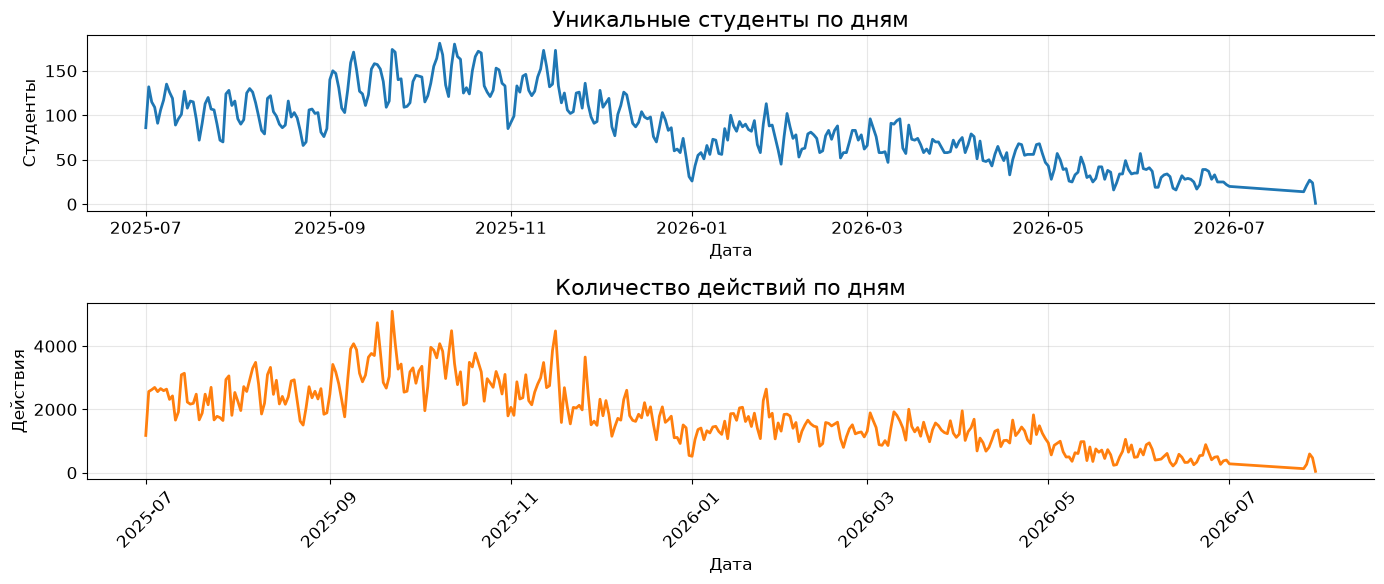

In [165]:
student_activity["date"] = pd.to_datetime(student_activity["date"])

fig, axes = plt.subplots(2, 1)
sns.lineplot(
    data=student_activity,
    x="date",
    y="unique_students",
    ax=axes[0],
    color="#1f77b4",
    linewidth=2
)
axes[0].set_title("Уникальные студенты по дням")
axes[0].set_ylabel("Студенты")
axes[0].set_xlabel("Дата")
sns.lineplot(
    data=student_activity,
    x="date",
    y="action_cnt",
    ax=axes[1],
    color="#ff7f0e",
    linewidth=2
)

axes[1].set_title("Количество действий по дням")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Действия")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Вывод

- Динамика общего числа действий и числа активных студентов во времени меняется синхронно: в периоды роста активности увеличивается как количество событий, так и число студентов, взаимодействующих с платформой.
- Число действий и число активных студентов меняются в одном направлении: пики и спады чаще происходят одновременно. Это указывает на связь между общим объёмом событий и числом пользователей с хотя бы одним действием за день. Однако по этим графикам нельзя определить, вызвано ли изменение активности изменением числа студентов, их интенсивности работы или обоих факторов.

In [166]:
query = """
with daily_activity AS (
  SELECT
    created_at::date AS date
    ,COUNT(DISTINCT user_id) AS unique_students
    ,COUNT(*) AS action_cnt
  FROM submissions
  GROUP BY created_at::date
)

SELECT
  date
  ,unique_students
  ,action_cnt
  ,ROUND(
    AVG(unique_students) OVER(ORDER BY date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)
    ,2
  ) AS unique_students_rolling_avg
  ,ROUND(
    AVG(action_cnt) OVER(ORDER BY date ROWS BETWEEN 6 PRECEDING AND CURRENT ROW) 
    ,2
  )AS action_cnt_rolling_avg
FROM daily_activity
"""

rolling_student_activity = read_query(query)
rolling_student_activity.head()

,date,unique_students,action_cnt,unique_students_rolling_avg,action_cnt_rolling_avg
0,2025-07-01,86,1178,86.0,1178.00
1,2025-07-02,132,2565,109.0,1871.50
2,2025-07-03,115,2622,111.0,2121.67
3,2025-07-04,109,2695,110.5,2265.00
4,2025-07-05,91,2562,106.6,2324.40


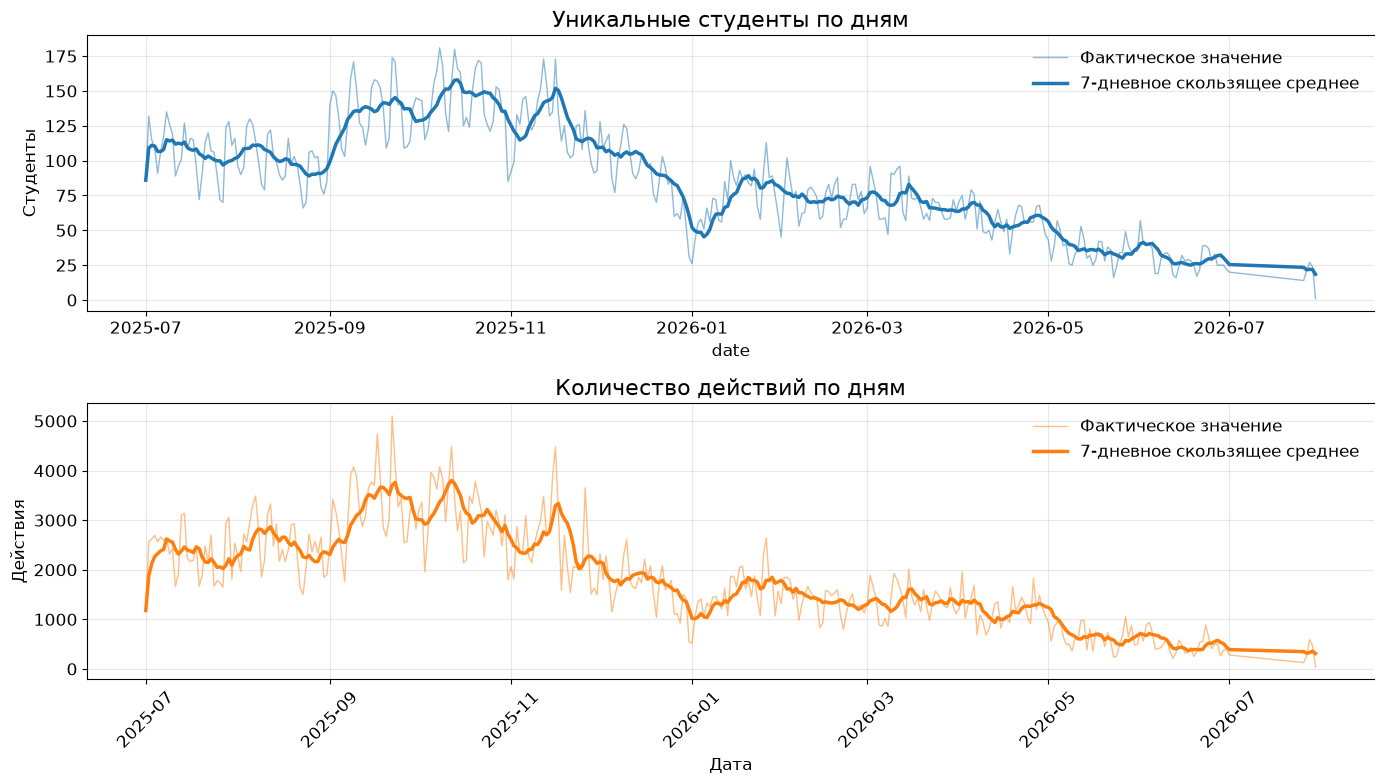

In [167]:
rolling_student_activity["date"] = pd.to_datetime(rolling_student_activity["date"])
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
sns.lineplot(
    data=rolling_student_activity,
    x="date",
    y="unique_students",
    ax=axes[0],
    color="#1f77b4",
    linewidth=1,
    alpha=0.5,
    label="Фактическое значение"
)
sns.lineplot(
    data=rolling_student_activity,
    x="date",
    y="unique_students_rolling_avg",
    ax=axes[0],
    color="#1f77b4",
    linewidth=2.5,
    label="7-дневное скользящее среднее"
)
axes[0].set_title("Уникальные студенты по дням")
axes[0].set_ylabel("Студенты")
axes[0].legend()
sns.lineplot(
    data=rolling_student_activity,
    x="date",
    y="action_cnt",
    ax=axes[1],
    color="#ff7f0e",
    linewidth=1,
    alpha=0.5,
    label="Фактическое значение"
)
sns.lineplot(
    data=rolling_student_activity,
    x="date",
    y="action_cnt_rolling_avg",
    ax=axes[1],
    color="#ff7f0e",
    linewidth=2.5,
    label="7-дневное скользящее среднее"
)
axes[1].set_title("Количество действий по дням")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Действия")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Вывод

- 7-дневное скользящее среднее показывает, что в последних наблюдаемых месяцах число активных студентов и количество действий ниже, чем в отдельные периоды второй половины 2025 года.
- Это описывает изменение активности в наблюдаемой выборке, но не доказывает долгосрочный нисходящий тренд. 


## Активность по дням недели и часам

**На какие вопросы отвечает блок**
1. В какие дни недели и часы студенты наиболее и наименее активны?
2. Есть ли устойчивые пики и спады внутри недели?
3. В какое время суток активность выше?

In [168]:
create_view_query = """
CREATE OR REPLACE VIEW v_daily_hour_actions AS
SELECT
    (created_at AT TIME ZONE 'Europe/Moscow')::date AS activity_date
    ,EXTRACT(ISODOW FROM (created_at AT TIME ZONE 'Europe/Moscow')::date) AS weekday_num
    ,CASE EXTRACT(ISODOW FROM (created_at AT TIME ZONE 'Europe/Moscow')::date)
        WHEN 1 THEN 'Понедельник'
        WHEN 2 THEN 'Вторник'
        WHEN 3 THEN 'Среда'
        WHEN 4 THEN 'Четверг'
        WHEN 5 THEN 'Пятница'
        WHEN 6 THEN 'Суббота'
        WHEN 7 THEN 'Воскресенье'
    END AS weekday_name
    ,EXTRACT(HOUR FROM created_at AT TIME ZONE 'Europe/Moscow') AS hour_num
    ,COUNT(*) AS action_cnt
FROM submissions
GROUP BY activity_date, weekday_num, weekday_name, hour_num
"""
with engine.begin() as conn:
    conn.execute(text(create_view_query))

In [169]:
query = """
WITH daily_actions AS (
  SELECT
    activity_date
    ,weekday_num
    ,weekday_name
    ,SUM(action_cnt) AS action_cnt
  FROM v_daily_hour_actions
  GROUP BY activity_date, weekday_num, weekday_name
)
SELECT
  weekday_num
  ,weekday_name
  ,ROUND(AVG(action_cnt), 2) AS avg_actions
  ,PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY action_cnt) AS median_actions
FROM daily_actions
GROUP BY weekday_num, weekday_name
ORDER BY weekday_num
"""
weekday_actions = read_query(query)
weekday_actions.head(7)


,weekday_num,weekday_name,avg_actions,median_actions
0,1.0,Понедельник,1996.11,1768.0
1,2.0,Вторник,1910.11,1720.5
2,3.0,Среда,1966.61,1789.0
3,4.0,Четверг,1819.70,1833.0
4,5.0,Пятница,1589.71,1501.5
5,6.0,Суббота,1547.38,1340.0
6,7.0,Воскресенье,1829.89,1829.0


In [170]:
weekday_long = weekday_actions.melt(
    id_vars=["weekday_num", "weekday_name"],
    value_vars=["avg_actions", "median_actions"],
    var_name="metric",
    value_name="actions"
)
weekday_long["metric"] = weekday_long["metric"].replace({
    "avg_actions": "Среднее",
    "median_actions": "Медиана"
})

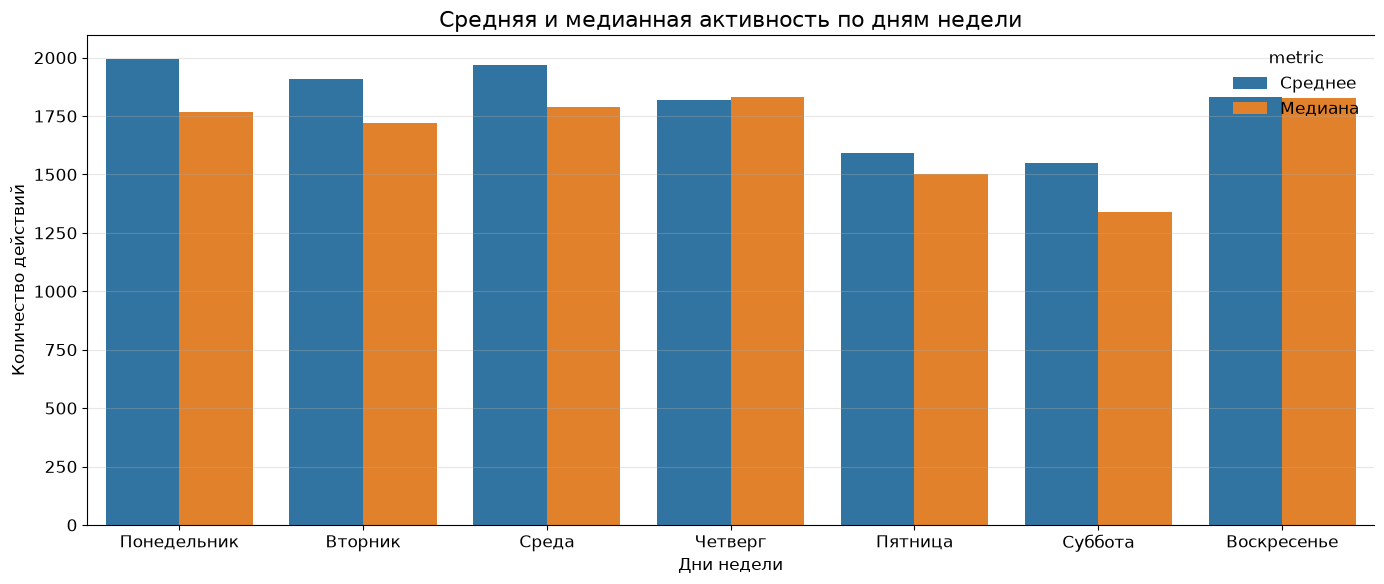

In [171]:
sns.barplot(
    data=weekday_long,
    x="weekday_name",
    y="actions",
    hue="metric"
)
plt.title("Средняя и медианная активность по дням недели")
plt.ylabel("Количество действий")
plt.xlabel("Дни недели")
plt.tight_layout()
plt.show()

In [172]:
query = """
SELECT
  hour_num
  ,ROUND(AVG(action_cnt), 2) AS avg_actions
  ,PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY action_cnt) AS median_actions
FROM v_daily_hour_actions
GROUP BY hour_num
ORDER BY hour_num
"""
hourly_actions = read_query(query)
hourly_actions.head()

,hour_num,avg_actions,median_actions
0,0.0,49.84,38.0
1,1.0,33.60,21.0
2,2.0,21.19,15.0
3,3.0,16.14,10.0
4,4.0,15.73,11.0


In [173]:
hourly_actions_long = hourly_actions.melt(
    id_vars='hour_num',    
    value_vars=['avg_actions', 'median_actions'],   
    var_name="metric",
    value_name="actions"  
)
hourly_actions_long["metric"] = hourly_actions_long["metric"].replace({
    "avg_actions": "Среднее",
    "median_actions": "Медиана"
})

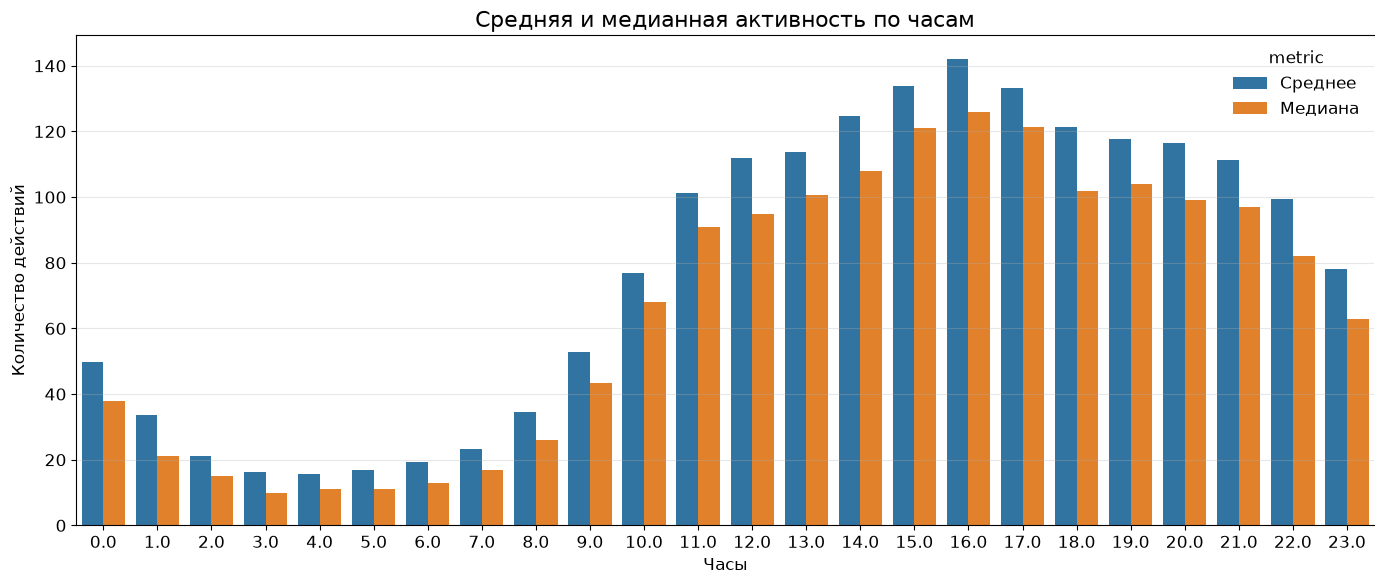

In [174]:
sns.barplot(
    data=hourly_actions_long,
    x="hour_num",
    y="actions",
    hue="metric"
)
plt.title("Средняя и медианная активность по часам")
plt.ylabel("Количество действий")
plt.xlabel("Часы")
plt.tight_layout()
plt.show()

In [175]:
query = """
SELECT
    weekday_num
    ,weekday_name
    ,hour_num
    ,ROUND(AVG(action_cnt), 2) AS avg_actions
FROM v_daily_hour_actions
GROUP BY weekday_num, weekday_name, hour_num
ORDER BY weekday_num, hour_num
"""
v_daily_hour_actions = read_query(query)
v_daily_hour_actions.head()

,weekday_num,weekday_name,hour_num,avg_actions
0,1.0,Понедельник,0.0,42.42
1,1.0,Понедельник,1.0,36.18
2,1.0,Понедельник,2.0,19.62
3,1.0,Понедельник,3.0,16.65
4,1.0,Понедельник,4.0,15.11


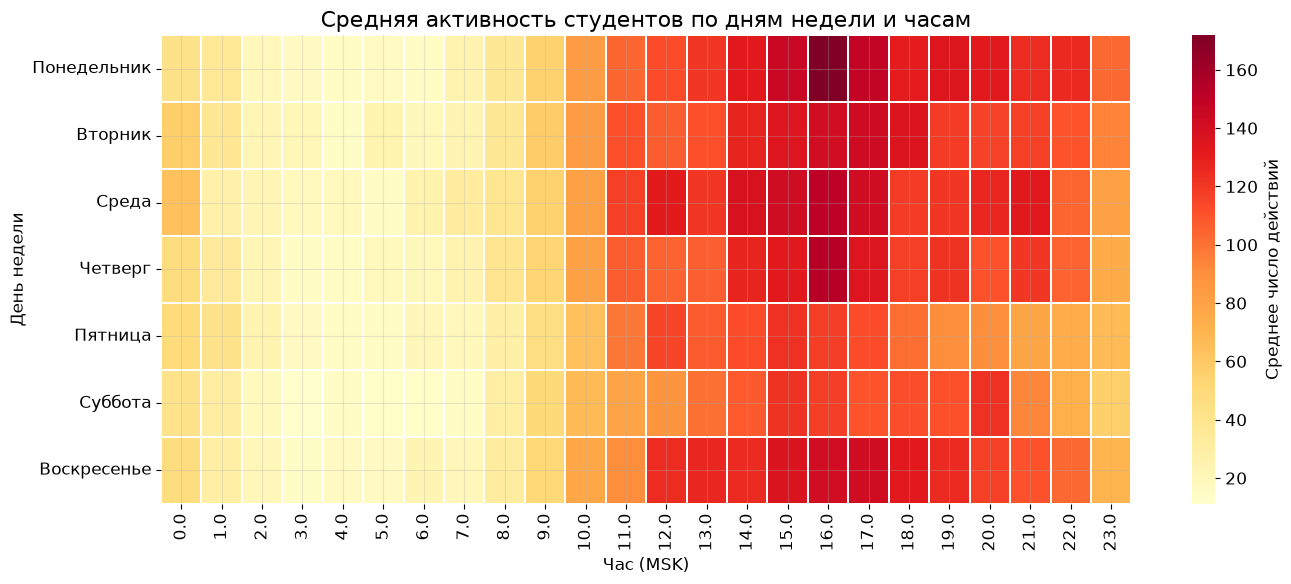

In [176]:
labels = (
    v_daily_hour_actions
    .sort_values("weekday_num")
    [["weekday_num", "weekday_name"]]
    .drop_duplicates()
)
heatmap_data = (
    v_daily_hour_actions
    .pivot(
        index="weekday_num",
        columns="hour_num",
        values="avg_actions"
    )
    .sort_index()
)

sns.heatmap(
    data=heatmap_data,
    cmap="YlOrRd",
    annot=False,
    fmt=".0f",
    linewidths=0.3,
    yticklabels=labels["weekday_name"],
    cbar_kws={"label": "Среднее число действий"}
)

plt.title("Средняя активность студентов по дням недели и часам")
plt.xlabel("Час (MSK)")
plt.ylabel("День недели")
plt.tight_layout()
plt.show()

### Вывод

- В наблюдаемом периоде среднее и медианное число действий по дням недели близки, поэтому общая картина не выглядит полностью определяемой единичными пиковыми днями.
- Активность ниже в пятницу и субботу, а в воскресенье возрастает относительно субботы. По часам активность увеличивается утром, достигает максимума примерно в середине дня и снижается вечером.


## Соотношение запусков и отправок решений

Смотрим долю `run` и `submit` в общей структуре действий.


In [177]:
query = """
WITH action_totals AS (
  SELECT 
    COUNT(attempt_type)::numeric AS total_cnt
    ,COUNT(
      CASE WHEN attempt_type = 'run' THEN 1 END
    ) AS run_cnt
    ,COUNT(
      CASE WHEN attempt_type = 'submit' THEN 1 END
    ) AS submit_cnt
  FROM submissions
)
SELECT
  total_cnt
  ,run_cnt
  ,submit_cnt
  ,ROUND(run_cnt / total_cnt, 2) as run_share
  ,ROUND(submit_cnt / total_cnt, 2 ) as submit_share
FROM action_totals
"""
action_totals = read_query(query)
action_totals

,total_cnt,run_cnt,submit_cnt,run_share,submit_share
0,671694.0,309234,362460,0.46,0.54


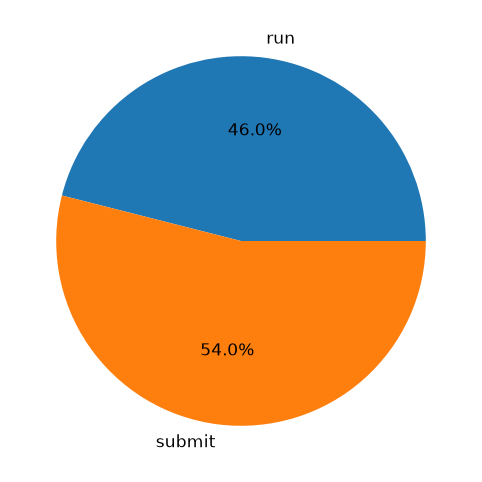

In [178]:
plt.pie(
    x=[
        action_totals.loc[0, "run_cnt"],
        action_totals.loc[0, "submit_cnt"]
    ],
    labels=["run", "submit"],
    autopct="%1.1f%%"
)

### Вывод

- За период наблюдения зарегистрировано 309 234 события run (46%) и 362 460 событий submit (54%). В этой выборке отправки решений встречаются немного чаще запусков кода.


## Результативность отправленных решений
Вопросы блока:
1. Какова доля успешных и неуспешных submit среди всех отправок?
2. Меняется ли success rate во времени, или вместе с общим спадом активности меняется только число попыток, а не доля успеха?

In [181]:
query = """ 
SELECT
  COUNT(*)::numeric AS total_submit_attempts
  ,COUNT(*) FILTER (WHERE is_correct = true) AS successful_submits_cnt
  ,COUNT(*) FILTER (WHERE is_correct = false) AS failed_submits_cnt
  ,ROUND(
    COUNT(*) FILTER (WHERE is_correct = true)::numeric / COUNT(*)
    , 2
  ) AS share_successful_submits
  ,ROUND(
    COUNT(*) FILTER (WHERE is_correct = false)::numeric / COUNT(*)
    , 2
  ) AS share_failed_submits
FROM submissions
WHERE attempt_type = 'submit'
"""
share_submits = read_query(query)
share_submits

,total_submit_attempts,successful_submits_cnt,failed_submits_cnt,share_successful_submits,share_failed_submits
0,362460.0,142847,219613,0.39,0.61


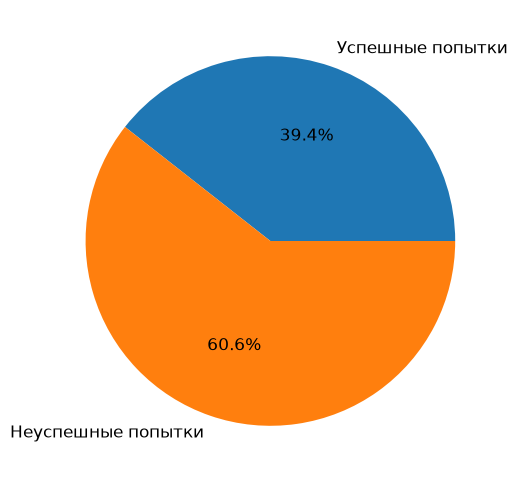

In [182]:
plt.pie(
    x=[
        share_submits.loc[0, "successful_submits_cnt"],
        share_submits.loc[0, "failed_submits_cnt"]
    ],
    labels=["Успешные попытки", "Неуспешные попытки"],
    autopct="%1.1f%%"
)

### Вывод

- Среди всех submit доля успешных попыток составляет `39%`: 142 847 успешных и 219 613 неуспешных отправок из 362 460.


In [183]:
query = """ 
WITH daily AS (
  SELECT
    created_at::date AS date
    ,COUNT(*)::numeric AS total_submit_attempts
    ,COUNT(*) FILTER (WHERE is_correct = true) AS successful_submits_cnt
    ,COUNT(*) FILTER (WHERE is_correct = false) AS failed_submits_cnt
    ,ROUND(
      COUNT(*) FILTER (WHERE is_correct = true)::numeric / COUNT(*)
      , 2
    ) AS share_successful_submits
  FROM submissions
  WHERE attempt_type = 'submit'
  GROUP BY created_at::date
  HAVING COUNT(*) >= 10
)
SELECT
  date
  ,total_submit_attempts
  ,successful_submits_cnt
  ,failed_submits_cnt
  ,share_successful_submits
  ,ROUND(
    AVG(share_successful_submits) OVER (
      ORDER BY date
      ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    )
    , 2
  ) AS success_rate_rolling_avg
FROM daily
ORDER BY date
"""
success_rate_by_day = read_query(query)
success_rate_by_day.head()

,date,total_submit_attempts,successful_submits_cnt,failed_submits_cnt,share_successful_submits,success_rate_rolling_avg
0,2025-07-01,739.0,368,371,0.50,0.50
1,2025-07-02,1554.0,532,1022,0.34,0.42
2,2025-07-03,1604.0,502,1102,0.31,0.38
3,2025-07-04,1213.0,446,767,0.37,0.38
4,2025-07-05,1569.0,474,1095,0.30,0.36


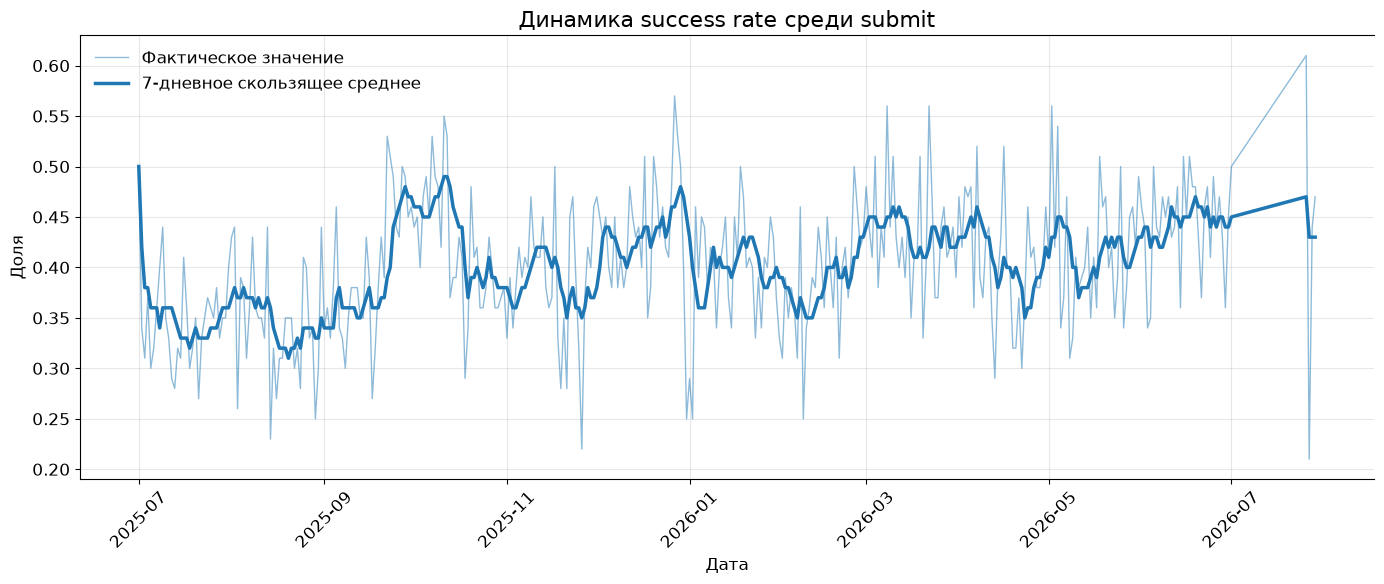

In [184]:
success_rate_by_day["date"] = pd.to_datetime(success_rate_by_day["date"])

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=success_rate_by_day,
    x="date",
    y="share_successful_submits",
    label="Фактическое значение",
    color="#1f77b4",
    linewidth=1,
    alpha=0.5
)

sns.lineplot(
    data=success_rate_by_day,
    x="date",
    y="success_rate_rolling_avg",
    label="7-дневное скользящее среднее",
    color="#1f77b4",
    linewidth=2.5
)

plt.title("Динамика success rate среди submit")
plt.xlabel("Дата")
plt.ylabel("Доля")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Вывод

- 7-дневное скользящее среднее показывает, что долю успешных попыток среди submit держится примерно около 0.4 на протяжении большей части периода.
- В отличие от абсолютного числа действий, доля успеха не демонстрирует такого же явного спада: меняется скорее объём попыток, а не их результативность.
- Для расчёта динамики исключены дни с менее чем 10 отправками submit: на таких днях доля слишком чувствительна к одной-двум попыткам и может принимать крайние значения 0 или 1. Порог выбран как простой фильтр шума и не меняет общую картину по дням с нормальной активностью.


## Распределение активности между студентами

**На какие вопросы отвечает блок**
1. Каковы среднее и медианное число действий на студента?
2. Насколько неравномерно распределена активность?

Считаем число действий на студента, сравниваем среднее с медианой и смотрим группы по уровню активности.


In [185]:
query = """
WITH actions_per_user AS (
  SELECT
    user_id
    ,COUNT(*) AS total_actions
  FROM submissions
  GROUP BY user_id
)
SELECT
  COUNT(*) AS total_users
  ,ROUND(AVG(total_actions), 2) AS avg_actions
  ,PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY total_actions) AS median_actions
  ,PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY total_actions) AS p90_actions
  ,PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY total_actions) AS p99_actions
  ,MIN(total_actions) AS min_actions
  ,MAX(total_actions) AS max_actions
FROM actions_per_user
"""

activity_summary = read_query(query)
activity_summary


,total_users,avg_actions,median_actions,p90_actions,p99_actions,min_actions,max_actions
0,4186,160.46,43.0,433.0,1635.9,1,4373


### Вывод
- Среднее число действий на студента - 160.46, медиана - 43.
- P90 ≈ 433, P99 ≈ 1636: то есть 90% студентов совершают не больше 433 действий, а экстремальные значения сосредоточены в верхнем хвосте.
- Минимум 1 и максимум 4373 подтверждают сильную асимметрию распределения.
- Среднее число действий не описывает типичное поведение студента: оно чувствительно к небольшой группе высокоактивных пользователей. Для описания типичного уровня активности уместнее использовать медиану. 


### Группы по уровню активности

Для более наглядного сравнения делим студентов на группы по числу действий и сравниваем две доли:
- долю студентов в группе;
- долю всех действий, которую эта группа создаёт.


In [188]:
query = """
WITH actions_per_user AS (
  SELECT
    user_id
    ,COUNT(*) AS total_actions
  FROM submissions
  GROUP BY user_id
)
SELECT
  CASE
    WHEN total_actions BETWEEN 1 AND 10 THEN '1–10'
    WHEN total_actions BETWEEN 11 AND 50 THEN '11–50'
    WHEN total_actions BETWEEN 51 AND 200 THEN '51–200'
    ELSE '200+'
  END AS activity_group
  ,COUNT(*) AS students_cnt
  ,SUM(total_actions) AS actions_cnt
  ,ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS students_share_pct
  ,ROUND(100.0 * SUM(total_actions) / SUM(SUM(total_actions)) OVER (), 2) AS actions_share_pct
FROM actions_per_user
GROUP BY 1
ORDER BY MIN(total_actions)
"""

activity_buckets = read_query(query)
activity_buckets


,activity_group,students_cnt,actions_cnt,students_share_pct,actions_share_pct
0,1–10,1007,4709.0,24.06,0.70
1,11–50,1216,32275.0,29.05,4.81
2,51–200,1080,114960.0,25.80,17.11
3,200+,883,519750.0,21.09,77.38


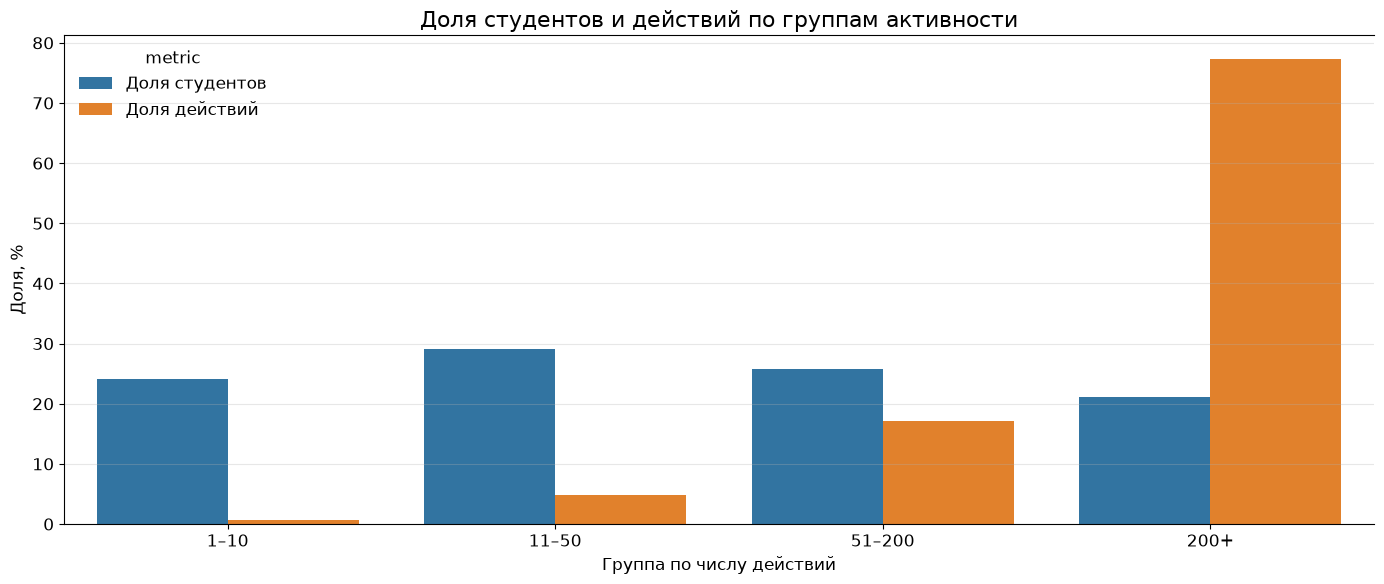

In [189]:
activity_buckets_plot = activity_buckets.melt(
    id_vars=["activity_group"],
    value_vars=["students_share_pct", "actions_share_pct"],
    var_name="metric",
    value_name="share_pct"
)
activity_buckets_plot["metric"] = activity_buckets_plot["metric"].replace({
    "students_share_pct": "Доля студентов",
    "actions_share_pct": "Доля действий"
})

plt.figure(figsize=(14, 6))
sns.barplot(
    data=activity_buckets_plot,
    x="activity_group",
    y="share_pct",
    hue="metric"
)
plt.title("Доля студентов и действий по группам активности")
plt.xlabel("Группа по числу действий")
plt.ylabel("Доля, %")
plt.tight_layout()
plt.show()


### Вывод

Активность между студентами распределена неравномерно.

- Группа `1–10` — около 24% студентов, но менее 1% всех действий.
- Группа `11–50` — около 29% студентов и примерно 5% действий.
- Группа `51–200` — около 26% студентов и около 17% действий.
- Группа `200+` — около 21% студентов, но уже около 77% всех событий.

Топ-10% самых активных студентов генерируют более половины всех действий (≈56%).
  
Отсюда следует главный вывод блока: объём событий в LMS в значительной степени определяется относительно небольшой группой высокоактивных пользователей, а среднее число действий на студента нельзя интерпретировать как показатель типичного поведения без медианы и анализа распределения.

## Возвращаемость студентов: D1, D7 и D30 retention

**На какие вопросы отвечает блок**
1. Какая доля студентов возвращается через 1, 7 и 30 дней после первой зафиксированной активности?

**Как считаем метрику**
- когорта студента — дата его первого события в данных;
- `DN retention` — доля студентов, у которых было хотя бы одно действие ровно на день `N` после первой активности;
- для каждой метрики учитываем только когорты с полным горизонтом наблюдения: для D1 — не позже `max_date - 1`, для D7 — `max_date - 7`, для D30 — `max_date - 30`.


In [191]:
query = """
WITH first_activity AS (
  SELECT
    user_id
    ,MIN(created_at::date) AS cohort_date
  FROM submissions
  GROUP BY user_id
)
,bounds AS (
  SELECT MAX(created_at::date) AS max_date
  FROM submissions
)
,activity_days AS (
  SELECT DISTINCT
    user_id
    ,created_at::date AS activity_date
  FROM submissions
)
,retention_base AS (
  SELECT
    f.user_id
    ,f.cohort_date
    ,b.max_date
    ,MAX(
      CASE WHEN a.activity_date = f.cohort_date + 1 THEN 1 ELSE 0 END
    ) AS retained_d1
    ,MAX(
      CASE WHEN a.activity_date = f.cohort_date + 7 THEN 1 ELSE 0 END
    ) AS retained_d7
    ,MAX(
      CASE WHEN a.activity_date = f.cohort_date + 30 THEN 1 ELSE 0 END
    ) AS retained_d30
  FROM first_activity f
  CROSS JOIN bounds b
  LEFT JOIN activity_days a
    ON a.user_id = f.user_id
   AND a.activity_date IN (
      f.cohort_date + 1
      ,f.cohort_date + 7
      ,f.cohort_date + 30
    )
  GROUP BY
    f.user_id
    ,f.cohort_date
    ,b.max_date
)
SELECT
  COUNT(*) FILTER (WHERE cohort_date <= max_date - 1) AS cohort_size_d1
  ,ROUND(
    AVG(
      CASE WHEN cohort_date <= max_date - 1 THEN retained_d1 END
    )::numeric
    , 3
  ) AS d1_retention
  ,COUNT(*) FILTER ( WHERE cohort_date <= max_date - 7) AS cohort_size_d7
  ,ROUND(
    AVG(
      CASE WHEN cohort_date <= max_date - 7 THEN retained_d7 END
    )::numeric
    , 3
  ) AS d7_retention
  ,COUNT(*) FILTER (WHERE cohort_date <= max_date - 30) AS cohort_size_d30
  ,ROUND(
    AVG(
      CASE WHEN cohort_date <= max_date - 30 THEN retained_d30 END
    )::numeric
    , 3
  ) AS d30_retention
FROM retention_base
"""

retention_overall = read_query(query)
retention_overall


,cohort_size_d1,d1_retention,cohort_size_d7,d7_retention,cohort_size_d30,d30_retention
0,4186,0.268,4170,0.13,4166,0.059


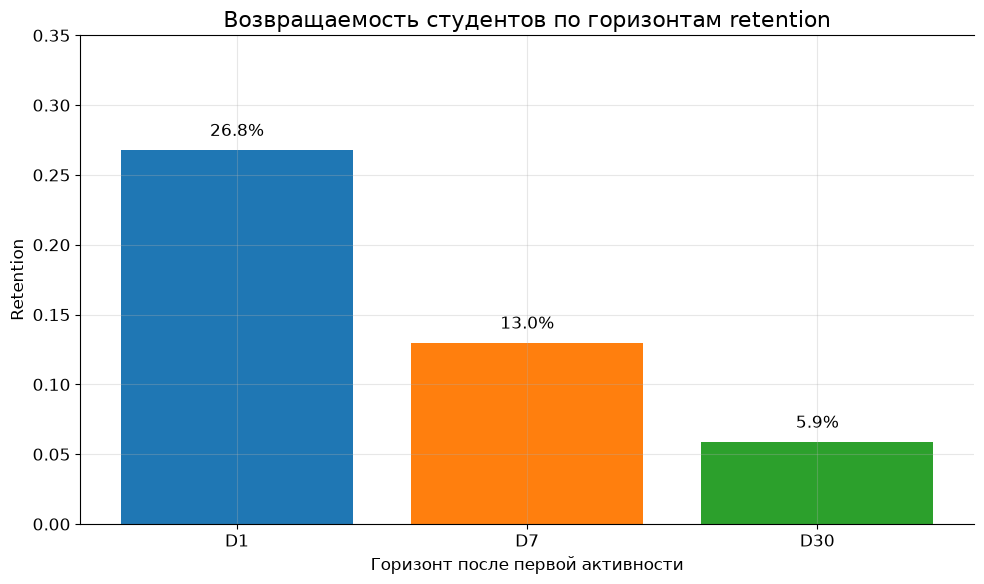

In [73]:
retention_plot = retention_overall.melt(
  value_vars=["d1_retention", "d7_retention", "d30_retention"],
  var_name="metric",
  value_name="retention",
)

retention_plot["metric"] = retention_plot["metric"].replace({
  "d1_retention": "D1",
  "d7_retention": "D7",
  "d30_retention": "D30",
})

retention_plot["metric"] = pd.Categorical(
  retention_plot["metric"],
  categories=["D1", "D7", "D30"],
  ordered=True,
)

retention_plot = retention_plot.sort_values("metric")

plt.figure(figsize=(10, 6))

bars = plt.bar(
  retention_plot["metric"],
  retention_plot["retention"],
  color=["#1f77b4", "#ff7f0e", "#2ca02c"],
)

for bar, value in zip(bars, retention_plot["retention"]):
  plt.text(
    bar.get_x() + bar.get_width() / 2,
    value + 0.01,
    f"{value:.1%}",
    ha="center",
  )

plt.title("Возвращаемость студентов по горизонтам retention")
plt.xlabel("Горизонт после первой активности")
plt.ylabel("Retention")
plt.ylim(0, 0.35)
plt.tight_layout()
plt.show()

### Вывод

- D1 retention = 26.8%: примерно каждый четвёртый студент возвращается на следующий день после первой зафиксированной активности.
- D7 retention = 13.0%: через неделю возвращаемость почти вдвое ниже.
- D30 retention = 5.9%: на горизонте месяца в журнале событий снова появляется лишь небольшая доля студентов.

Падение от D1 к D30 ожидаемо: чем дальше от первого дня, тем меньше студентов возвращается ровно в этот день.  
Метрика отражает возврат к решению задач на платформе. 

## Итог

- За период с 1 июля 2025 по 30 июля 2026 года в LMS зафиксировано 671 694 события от 4 186 студентов.
- Активность пользователей преимущественно приходится на дневные часы по московскому времени, а доля `submit` немного превышает долю `run` — 54% против 46%.
- В последних наблюдаемых месяцах объём событий и число активных студентов ниже, чем в ряде периодов 2025 года. Это наблюдение требует дополнительной проверки с учётом сезонности, набора студентов и учебного календаря.
- Success rate среди `submit` составляет около 39% и относительно стабилен во времени на фоне изменений объёма активности.
- Активность между студентами распределена неравномерно: медиана 43 действия против среднего 160, что указывает на концентрацию действий у небольшой группы пользователей.
- Retention после первой активности: D1 ≈ 27%, D7 ≈ 13%, D30 ≈ 6%.
- Анализ пригоден для мониторинга поведенческой активности в LMS, но не позволяет самостоятельно оценить качество обучения или установить причины изменения активности.
